# **Python Analysis Project - Swiggy Dataset 2025**

## **Import Libraries & Load Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### **Load data**

In [2]:
df = pd.read_csv("swiggy_data2025.csv")

#### **Basic info**

In [3]:
df.dtypes

State               object
City                object
Order Date          object
Restaurant Name     object
Location            object
Category            object
Dish Name           object
Price (INR)        float64
Rating             float64
Rating Count         int64
dtype: object

In [4]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,6/29/2025,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,4/3/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,1/15/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,4/17/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,3/13/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [5]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,1/25/2025,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,7/2/2025,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,3/25/2025,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,3/26/2025,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,3/27/2025,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


In [6]:
df.shape

(197430, 10)

In [7]:
df.columns.to_list()

['State',
 'City',
 'Order Date',
 'Restaurant Name',
 'Location',
 'Category',
 'Dish Name',
 'Price (INR)',
 'Rating',
 'Rating Count']

## **Data Cleaning & Feature Engineering**

#### **Check missing values**

In [8]:
df.isnull().sum()

State              0
City               0
Order Date         0
Restaurant Name    0
Location           0
Category           0
Dish Name          0
Price (INR)        0
Rating             0
Rating Count       0
dtype: int64

#### **Convert Order Date**

In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [10]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [11]:
df["Month"] = df["Order Date"].dt.month_name()
df["Month_num"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day_name()
df["Year"] = df["Order Date"].dt.year

In [12]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
Month                      object
Month_num                   int32
Day                        object
Year                        int32
dtype: object

## **Basic Statistics**

In [13]:
df.info

<bound method DataFrame.info of             State       City Order Date           Restaurant Name  \
0       Karnataka  Bengaluru 2025-06-29  Anand Sweets & Savouries   
1       Karnataka  Bengaluru 2025-04-03     Srinidhi Sagar Deluxe   
2       Karnataka  Bengaluru 2025-01-15     Srinidhi Sagar Deluxe   
3       Karnataka  Bengaluru 2025-04-17     Srinidhi Sagar Deluxe   
4       Karnataka  Bengaluru 2025-03-13     Srinidhi Sagar Deluxe   
...           ...        ...        ...                       ...   
197425     Sikkim    Gangtok 2025-01-25            Mama's Kitchen   
197426     Sikkim    Gangtok 2025-07-02            Mama's Kitchen   
197427     Sikkim    Gangtok 2025-03-25            Mama's Kitchen   
197428     Sikkim    Gangtok 2025-03-26            Mama's Kitchen   
197429     Sikkim    Gangtok 2025-03-27            Mama's Kitchen   

                    Location     Category  \
0       Rajarajeshwari Nagar        Snack   
1                    Kengeri  Recommended   
2   

In [14]:
df["Price (INR)"].describe()

count    197430.000000
mean        268.512920
std         219.338363
min           0.950000
25%         139.000000
50%         229.000000
75%         329.000000
max        8000.000000
Name: Price (INR), dtype: float64

In [15]:
df["Rating"].describe()

count    197430.000000
mean          4.341582
std           0.422585
min           1.500000
25%           4.300000
50%           4.400000
75%           4.500000
max           5.000000
Name: Rating, dtype: float64

In [16]:
print("Categories:",df["Category"].nunique())
print("Cities:",df["City"].nunique())
print("States:",df["State"].nunique())
print("Restaurants:",df["Restaurant Name"].nunique())
print("Dishes:",df["Dish Name"].nunique())

Categories: 4972
Cities: 28
States: 28
Restaurants: 993
Dishes: 59064


## **Top Cities Analysis**

#### **Top 10 cities by number of dishes**

In [17]:
top_cities = df["City"].value_counts().head(10)
top_cities

City
Bengaluru     20077
Mumbai        10507
Hyderabad     10309
Jaipur        10286
Lucknow       10192
New Delhi     10191
Ahmedabad     10185
Chandigarh    10065
Kolkata       10046
Chennai       10042
Name: count, dtype: int64

#### **Visualization**

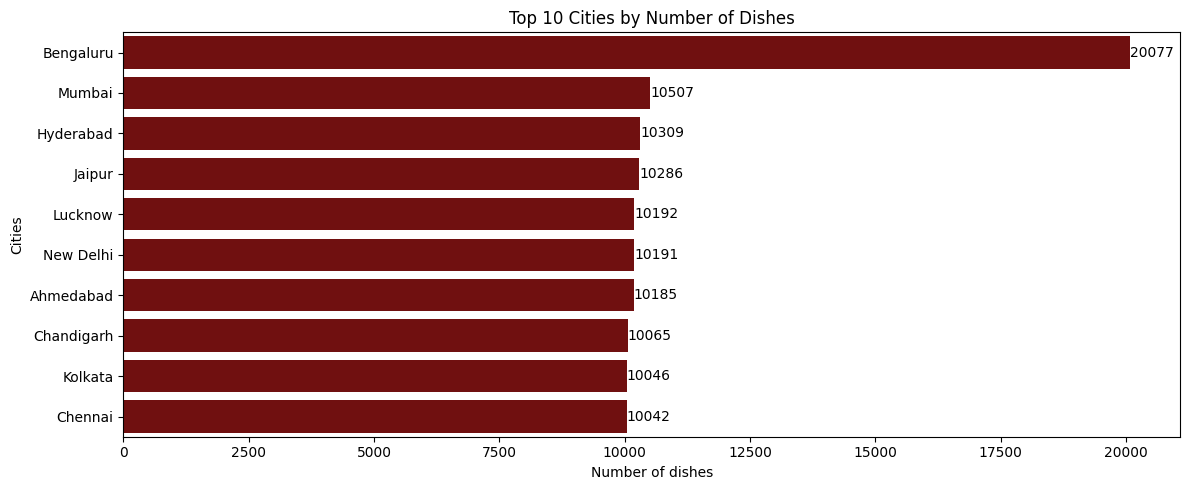

In [18]:
plt.figure(figsize= (12,5))
cx = sns.barplot(x=top_cities.values , y= top_cities.index , color="maroon")
for num in cx.containers:
    cx.bar_label(num , fmt= '%d' , label_type= 'edge')
plt.title("Top 10 Cities by Number of Dishes")
plt.xlabel("Number of dishes")
plt.ylabel("Cities")
plt.tight_layout()
plt.show()

## **Average Price & Rating by City**

In [19]:
city_status = df.groupby("City").agg({ 
    'Price (INR)':'mean' , 'Rating':'mean' , 'Dish Name':'count'
}).rename(columns={'Dish Name':'Dish_count'}).sort_values('Dish_count',ascending= False)
city_status.head(10).round(2)

,Price (INR),Rating,Dish_count
City,,,
Bengaluru,271.79,4.31,20077
Mumbai,287.01,4.34,10507
Hyderabad,293.11,4.27,10309
Jaipur,243.33,4.34,10286
Lucknow,305.86,4.37,10192
New Delhi,277.62,4.34,10191
Ahmedabad,276.67,4.39,10185
Chandigarh,279.13,4.34,10065
Kolkata,265.06,4.41,10046


## **Top Restaurants**

#### **Top 15 restaurants by number of dishes**

In [20]:
top_rest = df["Restaurant Name"].value_counts().head(15)
print(top_rest)

Restaurant Name
McDonald's                             13530
KFC                                    12961
Burger King                             7116
Pizza Hut                               6529
Domino's Pizza                          5492
LunchBox - Meals and Thalis             4700
Baskin Robbins - Ice Cream Desserts     4197
Faasos - Wraps, Rolls & Shawarma        3256
Olio - The Wood Fired Pizzeria          3241
The Good Bowl                           2665
Veg Meals by Lunchbox                   2083
La Pino'z Pizza                         2079
Wow! Momo                               2011
Sweet Truth - Cake and Desserts         1761
Chinese Wok                             1339
Name: count, dtype: int64


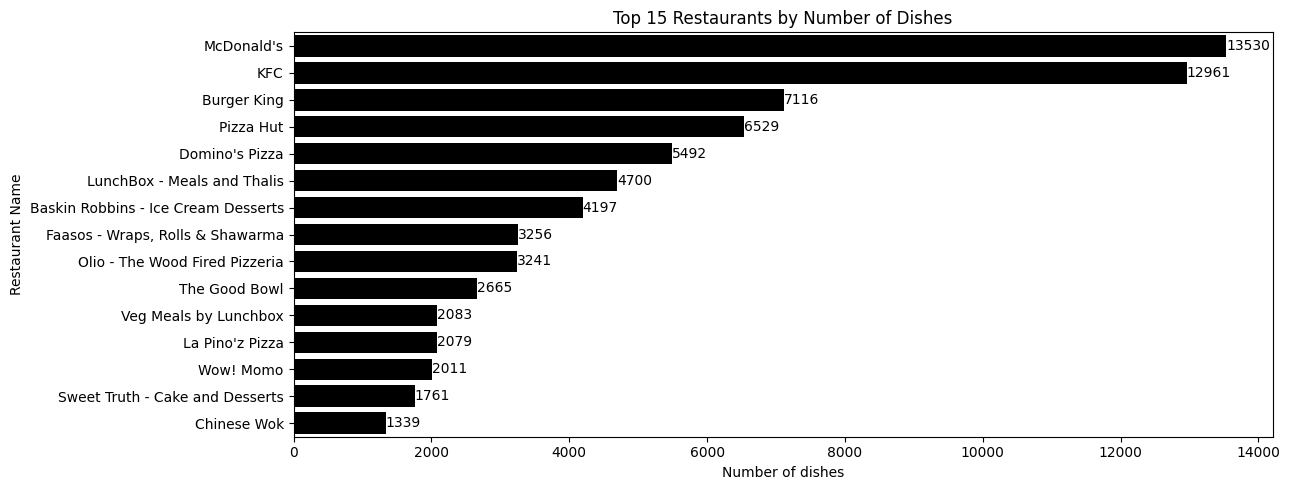

In [21]:
plt.figure(figsize=(13,5))
bx = sns.barplot(x= top_rest.values , y = top_rest.index , color = "black")
for line in bx.containers: 
    bx.bar_label(line , fmt= '%d' , label_type= 'edge')
plt.title("Top 15 Restaurants by Number of Dishes")
plt.xlabel("Number of dishes")
plt.tight_layout()
plt.show()

## **Highest Rated Restaurants (with filter)**

#### **Restaurants with at least 50 total rating counts**

In [22]:
rest_rating = df.groupby("Restaurant Name").agg({
    'Price (INR)': 'mean',
    'Rating': 'mean',
    'Rating Count': 'sum'
}).reset_index()
high_rating = rest_rating[rest_rating["Rating Count"] >= 50].sort_values('Rating', ascending = False)
print(high_rating.head(15).round(2))

                            Restaurant Name  Price (INR)  Rating  Rating Count
733                                  Sakana       484.32    4.82          2155
411            Jagannath Mandir Arna Prasad        58.75    4.75           288
958                             Vijay Dairy       165.87    4.75           539
686           Radhey Lal's Parampara Sweets       225.00    4.74         12090
390                             I Deli Cafe       148.68    4.74          3600
981                       Yadav Doodh Dairy       449.16    4.73          2609
924                            Tossin Pizza       495.62    4.71          8978
639  Perambur Sri Srinivasa Sweets & Snacks       109.15    4.70           244
973                            Wooden Plate       350.74    4.69          4257
578                       Natural Ice Cream       232.57    4.68         11567
120                       Bombay Sweet Shop       463.83    4.68           372
273                                Euphoria       40

## **Price Distribution**

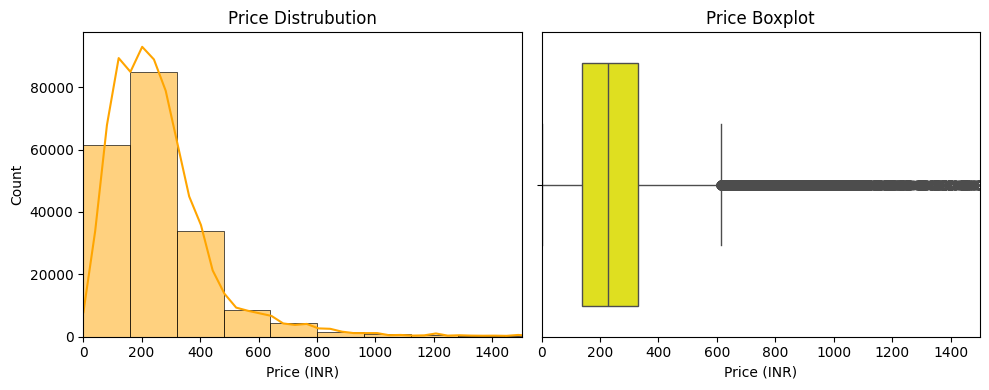

In [23]:
plt.figure(figsize=(10,4))
plt.subplot(1 ,2 ,1)
sns.histplot(df["Price (INR)"], bins= 50,kde= True ,color="orange")
plt.title("Price Distrubution")
plt.xlim(0,1500)
plt.subplot(1, 2, 2)
sns.boxplot(x=df["Price (INR)"],color="yellow")
plt.title("Price Boxplot")
plt.xlim(0,1500)
plt.tight_layout()
plt.show()

## **Top Categories**

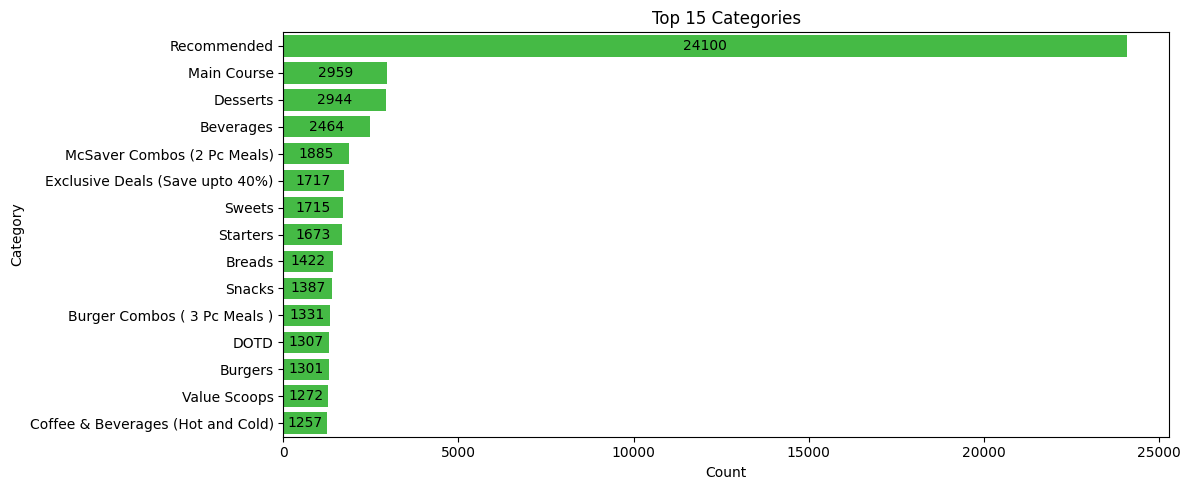

In [24]:
top_cat = df["Category"].value_counts().head(15)
top_cat
plt.figure(figsize=(12,5))
ax = sns.barplot(x=top_cat.values ,y = top_cat.index , color= "limegreen")
for bar in ax.containers:
    ax.bar_label(bar , fmt='%d' , label_type= 'center')
plt.title("Top 15 Categories")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

## **Average Price & Rating by Category**

In [25]:
cat_stats = df.groupby("Category").agg({
    'Price (INR)': 'mean',
    'Rating': 'mean',
    'Dish Name': 'count'
}).rename(columns = {'Dish Name':'Count'}).sort_values("Count" , ascending = False)
print(cat_stats.head(15).round(2))

                                   Price (INR)  Rating  Count
Category                                                     
Recommended                             298.30    4.32  24100
Main Course                             256.86    4.31   2959
Desserts                                141.41    4.37   2944
Beverages                                91.45    4.37   2464
McSaver Combos (2 Pc Meals)             229.02    4.41   1885
Exclusive Deals (Save upto 40%)         223.28    4.35   1717
Sweets                                  226.12    4.46   1715
Starters                                238.35    4.30   1673
Breads                                   85.17    4.35   1422
Snacks                                  126.50    4.31   1387
Burger Combos ( 3 Pc Meals )            381.50    4.38   1331
DOTD                                    260.80    4.31   1307
Burgers                                 249.26    4.36   1301
Value Scoops                            114.69    4.38   1272
Coffee &

## **Price vs Rating Relationship**

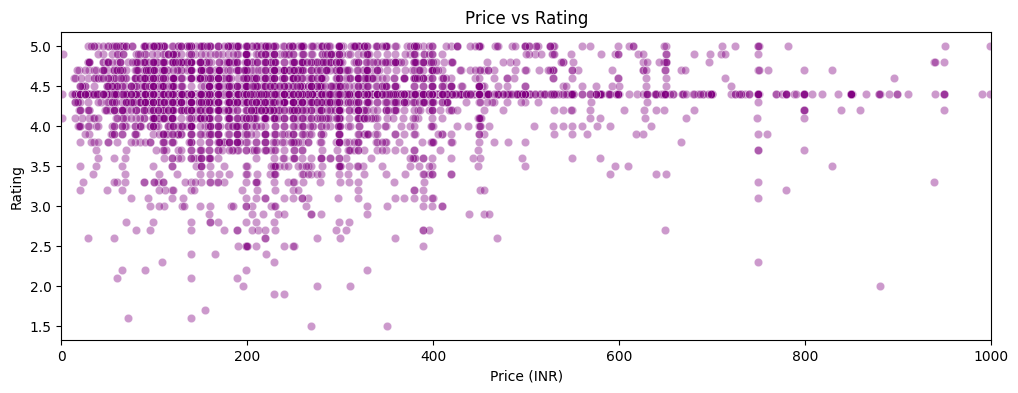

Correlation: 0.029


In [26]:
plt.figure(figsize=(12,4))
sns.scatterplot(data= df.sample(5000), x = 'Price (INR)', y='Rating', alpha=0.4, color='purple')
plt.title("Price vs Rating")
plt.xlim(0, 1000)
plt.show()
print("Correlation:", df['Price (INR)'].corr(df['Rating']).round(3))

## **Value for Money Score (Very Important)**

In [27]:
df['Value_Score'] = (df['Rating'] * np.log1p(df['Rating Count'])) / (df['Price (INR)'] + 1)
df['Value_Score'] 

0         0.000000
1         0.276631
2         0.155013
3         0.292006
4         0.000000
            ...   
197425    0.000000
197426    0.000000
197427    0.000000
197428    0.000000
197429    0.000000
Name: Value_Score, Length: 197430, dtype: float64

In [28]:
top_value = df.nlargest(3, 'Value_Score')[['City', 'Restaurant Name', 'Dish Name', 'Price (INR)', 'Rating', 'Rating Count', 'Value_Score']]
top_value = top_value.round(2)
top_value

,City,Restaurant Name,Dish Name,Price (INR),Rating,Rating Count,Value_Score
154257,Raipur,Pizza Hut,Tomato Ketchup,0.95,4.2,479,13.30
3158,Bengaluru,McDonald's,Tomato Ketchup Sachet,1.00,4.4,383,13.09
175389,Agartala,Pizza Hut,Tomato Ketchup,0.95,4.3,370,13.05


## **Monthly Trend**

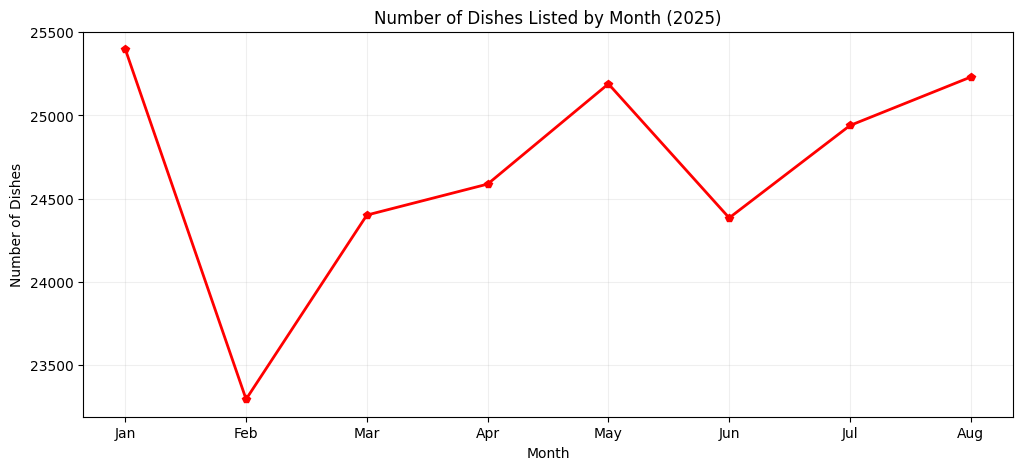

In [29]:
monthly = df.groupby('Month_num').size()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug']
plt.figure(figsize=(12, 5))
plt.plot(month_names, monthly.values, marker='p', linewidth=2, color='red')
plt.title("Number of Dishes Listed by Month (2025)")
plt.xlabel("Month")
plt.ylabel("Number of Dishes")
plt.grid(True, alpha=0.2)
plt.show()

## **Day of Week Analysis**

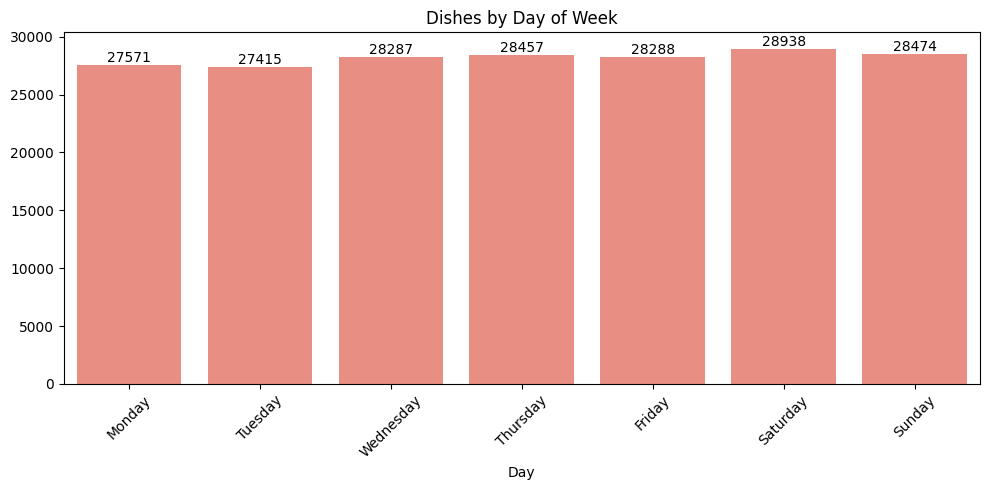

In [30]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['Day'].value_counts().reindex(day_order)
plt.figure(figsize=(10, 5))
dx = sns.barplot(x=day_counts.index, y=day_counts.values, color= 'salmon')
for good in dx.containers:
    dx.bar_label(good , fmt= '%d' , label_type= 'edge')
plt.title("Dishes by Day of Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Key Business Insights**

1. **Bengaluru** has the highest number of dishes listed.
2. Average dish price across India is around ₹268.
3. Most dishes are priced between ₹100 – ₹350.
4. Categories like "Recommended", "Main Course", and "Desserts" dominate.
5. There is almost **no strong correlation** between Price and Rating.
6. High Value-for-Money dishes are mostly under ₹200 with good ratings.
7. Some smaller cities have higher average prices than metro cities.
8. Rating Count is highly skewed — many dishes have 0 ratings.

## **Recommendations**

- Focus marketing on high Value-for-Money dishes.
- Encourage customers to rate more dishes (many have 0 ratings).
- Restaurants in high-price cities can introduce more budget options.
- "Recommended" category performs well — restaurants should optimize this section.

## *Conclusion*

**In this project, we analyzed Swiggy food delivery data from 28 Indian cities covering the period from January to August 2025. The dataset contained nearly 200,000 dish listings across hundreds of restaurants.**

### *Final Thoughts*
**This analysis provides useful insights into pricing patterns, customer preferences, and restaurant performance on Swiggy. The findings can help restaurants optimize their menus and pricing strategies, while also helping customers discover better value options.**

**Overall, this project demonstrates the power of data analysis in understanding the food delivery market in India.**